In [34]:
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots

import sklearn.model_selection as skm        # alias identico
from sklearn.tree import (DecisionTreeClassifier as DTC,
                          plot_tree, export_text)
from sklearn.metrics import (accuracy_score, log_loss)

from sklearn.ensemble import (RandomForestRegressor as RF,   # li userai dopo
                              GradientBoostingRegressor as GBR)

from ISLP.models import ModelSpec as MS          # stessa utility ISLP


In [35]:
df = pd.read_csv("Data/aircraft_price_clean.csv")

# Definisci la classe positiva: prezzo sopra la mediana
thr = df["price"].median()
df["HighPrice"] = np.where(df["price"] > thr, "Yes", "No")


In [36]:
# 1) prendi solo le feature
X_df = df.drop(columns=['price','HighPrice'])

# 2) one-hot encoding rapido di TUTTE le object/categorical
D = pd.get_dummies(X_df, drop_first=False)
feature_names = D.columns.tolist()

# 3) matrice numpy
X = D.values
y = df['HighPrice']

# adesso puoi fare
clf = DTC(criterion='entropy', random_state=0)
clf.fit(X, y)



DecisionTreeClassifier(criterion='entropy', random_state=0)

In [37]:
#accuracy 
y_pred = clf.predict(X)
acc = accuracy_score(y, y_pred)
print(f"Accuracy: {acc:.3f}")


Accuracy: 1.000


In [38]:
resid_dev = np.sum(log_loss(y, clf.predict_proba(X)))
resid_dev


2.2204460492503136e-16

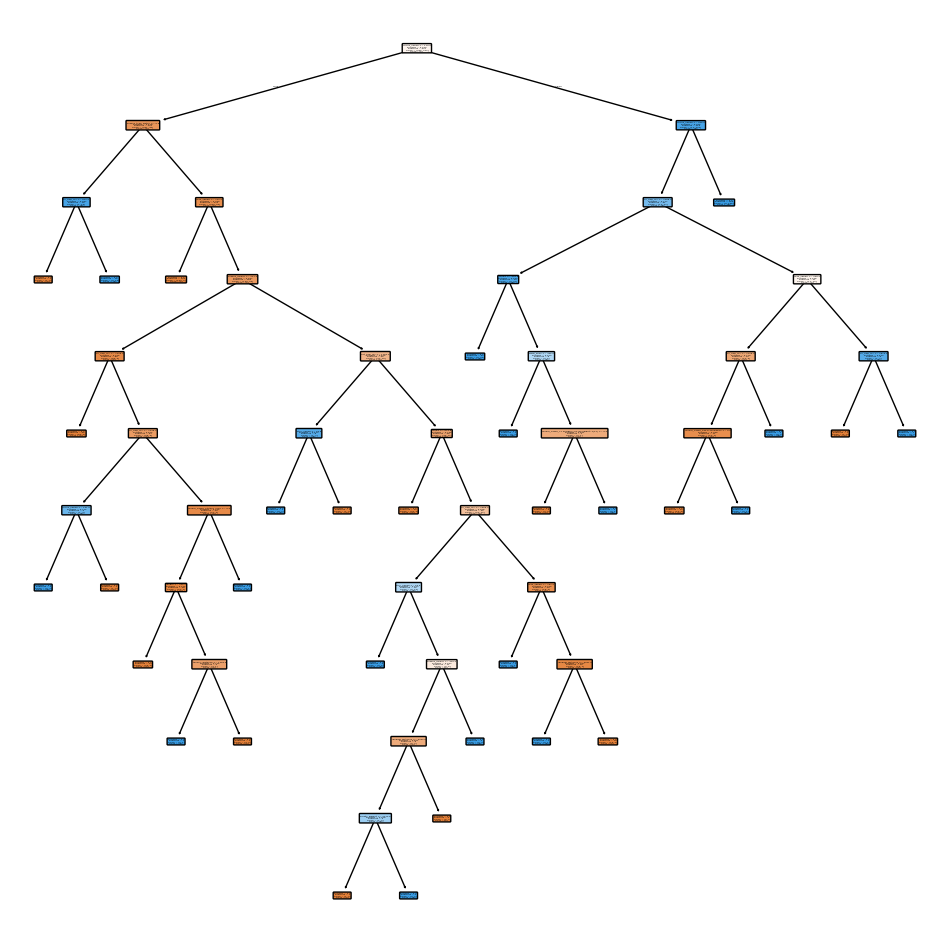

In [39]:
ax = subplots(figsize=(12, 12))[1]
plot_tree(clf,
          feature_names = feature_names,
          class_names   = ["No", "Yes"],
          filled        = True,
          rounded       = True,
          ax            = ax);


In [40]:
print(export_text(clf,
                  feature_names = feature_names,
                  show_weights  = True))


|--- cruise_speed <= 179.50
|   |--- engine_type_Piston <= 0.50
|   |   |--- all_eng_roc <= 812.50
|   |   |   |--- weights: [1.00, 0.00] class: No
|   |   |--- all_eng_roc >  812.50
|   |   |   |--- weights: [0.00, 15.00] class: Yes
|   |--- engine_type_Piston >  0.50
|   |   |--- max_speed <= 142.50
|   |   |   |--- weights: [120.00, 0.00] class: No
|   |   |--- max_speed >  142.50
|   |   |   |--- engine_power <= 247.50
|   |   |   |   |--- all_eng_roc <= 1105.00
|   |   |   |   |   |--- weights: [55.00, 0.00] class: No
|   |   |   |   |--- all_eng_roc >  1105.00
|   |   |   |   |   |--- all_eng_roc <= 1135.00
|   |   |   |   |   |   |--- cruise_speed <= 161.50
|   |   |   |   |   |   |   |--- weights: [0.00, 4.00] class: Yes
|   |   |   |   |   |   |--- cruise_speed >  161.50
|   |   |   |   |   |   |   |--- weights: [1.00, 0.00] class: No
|   |   |   |   |   |--- all_eng_roc >  1135.00
|   |   |   |   |   |   |--- model_name_Citation I 500 <= 0.50
|   |   |   |   |   |   |   |--- 

In [41]:
(X_train, X_test,
 y_train, y_test) = skm.train_test_split(
    X, y, test_size=0.5, random_state=0, stratify=y)

clf = DTC(criterion='entropy', random_state=0)
clf.fit(X_train, y_train)
print("Test accuracy:", round(accuracy_score(y_test, clf.predict(X_test)), 3))


Test accuracy: 0.917


In [42]:
# 8.1  estrai il percorso di pruning
ccp_path = clf.cost_complexity_pruning_path(X_train, y_train)

# 8.2  10-fold CV per scegliere ccp_alpha
kfold = skm.KFold(10, shuffle=True, random_state=1)

grid = skm.GridSearchCV(
    clf,
    {'ccp_alpha': ccp_path.ccp_alphas},
    cv        = kfold,
    scoring   = 'accuracy',
    refit     = True)

grid.fit(X_train, y_train)
print("Best CV accuracy:", grid.best_score_.round(3))
best_ = grid.best_estimator_

# 8.3  accuracy sul test set
print("Test accuracy:", round(accuracy_score(y_test, best_.predict(X_test)), 3))

Best CV accuracy: 0.929
Test accuracy: 0.898


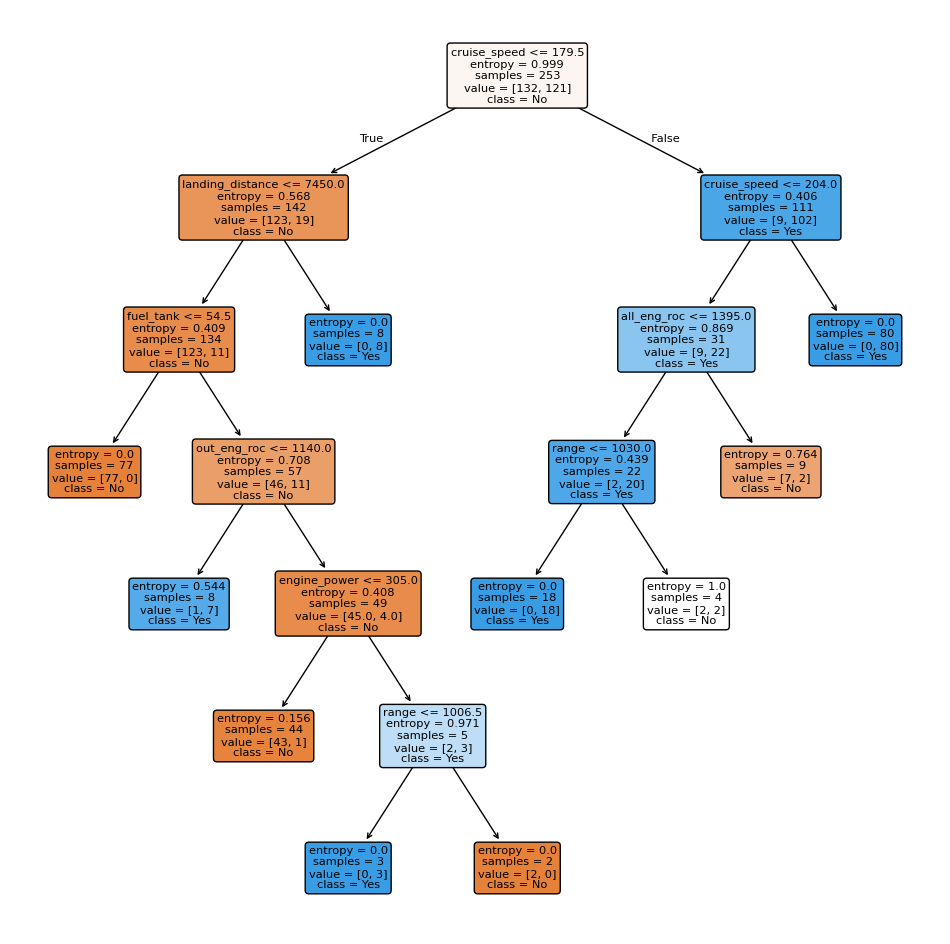

In [43]:
ax = subplots(figsize=(12, 12))[1]
plot_tree(best_,
          feature_names = feature_names,
          class_names   = ["No", "Yes"],
          filled        = True,
          rounded       = True,
          ax            = ax);


In [44]:
#AUC
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
from sklearn.metrics import auc
from sklearn.metrics import RocCurveDisplay

y_pred_proba = best_.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba, pos_label='Yes')
roc_auc = auc(fpr, tpr)
print(f"ROC AUC: {roc_auc:.3f}")


ROC AUC: 0.949


In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline      import Pipeline
from sklearn.compose       import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree          import DecisionTreeClassifier
from sklearn.metrics       import classification_report, confusion_matrix

# 1) Carica
df = pd.read_csv("Data/aircraft_price_clean.csv")

# 2) Target multi‐classe
y = df["engine_type"]        # “Piston” / “Propjet” / “Jet”
X = df.drop(columns=["engine_type","model_name","price"])

# 3) Preprocess
cat_cols = X.select_dtypes(include=["object","category"]).columns.tolist()
num_cols = X.select_dtypes(include=np.number).columns.tolist()

preproc = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
], remainder="passthrough")

# 4) Pipeline con Decision Tree
pipe = Pipeline([
    ("prep", preproc),
    ("clf", DecisionTreeClassifier(max_depth=5, random_state=11))
])

# 5) Train/Test
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=11
)
pipe.fit(X_tr, y_tr)

# 6) Valutazione
y_pred = pipe.predict(X_te)
print(classification_report(y_te, y_pred, digits=3))
print("Confusion matrix:\n", confusion_matrix(y_te, y_pred))

# 7) (Opzionale) CV
scores = cross_val_score(pipe, X, y, cv=5, scoring="accuracy")
print("CV accuracy: ", scores.mean().round(3), "±", scores.std().round(3))


              precision    recall  f1-score   support

         Jet      0.952     0.952     0.952        21
      Piston      0.991     0.991     0.991       114
     Propjet      0.944     0.944     0.944        18

    accuracy                          0.980       153
   macro avg      0.963     0.963     0.963       153
weighted avg      0.980     0.980     0.980       153

Confusion matrix:
 [[ 20   0   1]
 [  1 113   0]
 [  0   1  17]]
CV accuracy:  0.955 ± 0.024


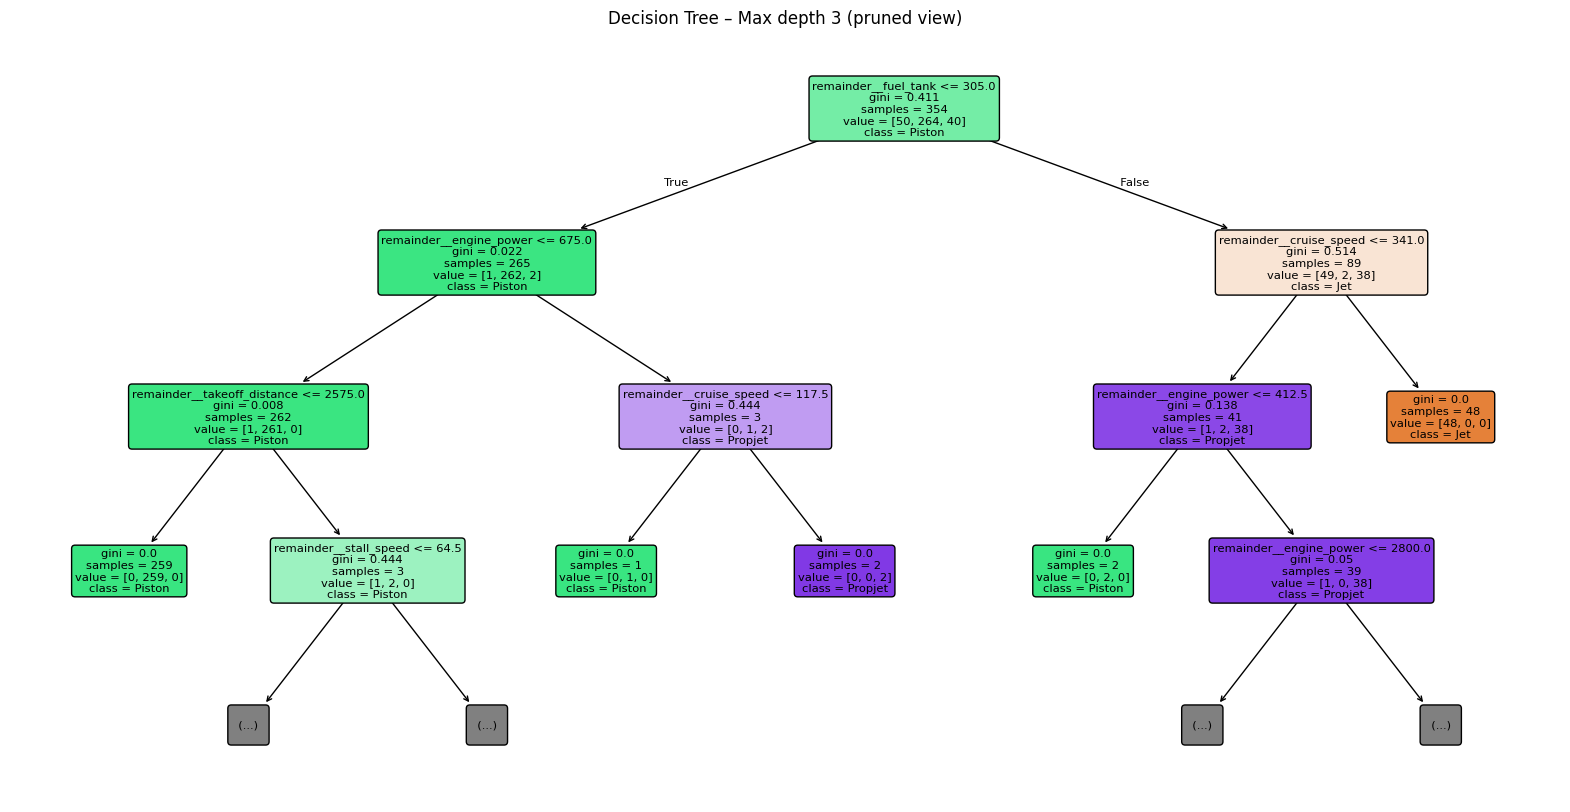

In [48]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Access the decision tree classifier from the pipeline
tree = pipe.named_steps["clf"]

# Get feature names from the preprocessing step
feature_names = pipe.named_steps["prep"].get_feature_names_out()

plt.figure(figsize=(20, 10))
plot_tree(tree, feature_names=feature_names, class_names=tree.classes_,
          filled=True, rounded=True, max_depth=3)  # per leggibilità
plt.title("Decision Tree – Max depth 3 (pruned view)")
plt.show()


In [49]:
ccp_path = tree.cost_complexity_pruning_path(X_tr, y_tr)
alphas = ccp_path.ccp_alphas

from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

grid = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=11),
    param_grid={"ccp_alpha": alphas},
    scoring="accuracy",
    cv=5
)

grid.fit(X_tr, y_tr)
best_tree = grid.best_estimator_
print("Best depth:", best_tree.get_depth())


Best depth: 3
